# MPC-Controlled Differential Drive Robot

Simulate a differential drive robot navigating to target $(x_t, y_t)$ using **Model Predictive Control (MPC)** — an optimal control strategy that solves an optimization problem at each time step.

### Kinematics (Unicycle Model)

$$
\begin{bmatrix}
\dot{x} \\ \dot{y} \\ \dot{\theta}
\end{bmatrix}
=
\begin{bmatrix}
v \cos\theta \\
v \sin\theta \\
\omega
\end{bmatrix}
$$

### Dynamics (with Friction)

$$
m\dot{v} = u_v - b_v v, \qquad
I\dot{\omega} = u_\omega - b_\omega \omega
$$

### MPC Formulation

At each sampling instant $k$, MPC solves:

$$
\min_{U_k} \sum_{j=0}^{N-1} \big( \mathbf{e}_{k+j|k}^\mathsf{T} Q \, \mathbf{e}_{k+j|k} + u_{k+j|k}^\mathsf{T} R \, u_{k+j|k} \big)
$$

subject to the discretized dynamics:

$$
\mathbf{x}_{k+j+1|k} = f(\mathbf{x}_{k+j|k}, u_{k+j|k})
$$

where $\mathbf{e} = [e_d,\; e_\theta]^\mathsf{T}$ are the distance and heading errors, $N$ is the prediction horizon, and $Q, R$ weigh state error vs. control effort. Only the first control $u_{k|k}$ is applied; the horizon then recedes.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

print("Libraries loaded.")

Libraries loaded.


## 1. Discrete-Time Model for MPC

The continuous dynamics are discretized with time step $\Delta t$ for use inside the MPC optimizer.

$$
\begin{aligned}
x_{k+1} &= x_k + \Delta t\; v_k \cos\theta_k \\
y_{k+1} &= y_k + \Delta t\; v_k \sin\theta_k \\
\theta_{k+1} &= \theta_k + \Delta t\; \omega_k \\
v_{k+1} &= v_k + \Delta t\; (u_{v,k} - b_v v_k)/m \\
\omega_{k+1} &= \omega_k + \Delta t\; (u_{\omega,k} - b_\omega \omega_k)/I
\end{aligned}
$$

In [2]:
# Robot parameters (same as PID/LQR extras)
m = 1.0
I = 0.5
b_v = 0.8
b_omega = 0.4

# Target position
x_target = -4.0
y_target = 10.0

# MPC parameters
dt = 0.1            # sampling time (s)
N = 15              # prediction horizon (steps)
Q = np.diag([10.0, 10.0])   # state error weights: [e_d, e_theta]
R = np.diag([1.0, 1.0])     # control effort weights: [u_v, u_omega]

# Control limits (constraints)
v_max = 5.0
omega_max = 5.0
u_v_max = 10.0
u_omega_max = 10.0

## 2. MPC Controller

At each time step, `compute_mpc` solves the constrained optimisation problem using `scipy.optimize.minimize` with the L-BFGS-B method. The decision variable is the stacked control sequence over the horizon: $U = [u_{v,0}, u_{\omega,0}, u_{v,1}, u_{\omega,1}, \dots, u_{v,N-1}, u_{\omega,N-1}]$.

In [3]:
def discrete_dynamics(x, u):
    """One-step forward Euler."""
    x_next = x.copy()
    x_next[0] += dt * x[3] * np.cos(x[2])
    x_next[1] += dt * x[3] * np.sin(x[2])
    x_next[2] += dt * x[4]
    x_next[3] += dt * (u[0] - b_v * x[3]) / m
    x_next[4] += dt * (u[1] - b_omega * x[4]) / I
    return x_next


def compute_mpc(x_current, x_target, y_target):
    """Solve the MPC optimisation over horizon N."""
    def cost(U_flat):
        U = U_flat.reshape(-1, 2)
        x_sim = x_current.copy()
        J = 0.0
        for j in range(N):
            dx = x_target - x_sim[0]
            dy = y_target - x_sim[1]
            e_dist = np.hypot(dx, dy)
            theta_target = np.arctan2(dy, dx)
            e_theta = theta_target - x_sim[2]
            e_theta = np.arctan2(np.sin(e_theta), np.cos(e_theta))
            J += Q[0, 0] * e_dist**2 + Q[1, 1] * e_theta**2
            J += R[0, 0] * U[j, 0]**2 + R[1, 1] * U[j, 1]**2
            x_sim = discrete_dynamics(x_sim, U[j])
        return J

    n_vars = N * 2
    U0 = np.zeros(n_vars)

    # Bounds: |u_v| <= u_v_max, |u_omega| <= u_omega_max
    bounds = [(-u_v_max, u_v_max), (-u_omega_max, u_omega_max)] * N

    res = minimize(cost, U0, method='L-BFGS-B', bounds=bounds,
                   options={'maxiter': 200, 'ftol': 1e-6})

    U_opt = res.x.reshape(-1, 2)
    # Return only the first control action (receding horizon)
    return U_opt[0]

## 3. Closed-Loop Simulation

The robot is simulated by integrating the continuous ODE with `solve_ivp` over short intervals, using the MPC-computed control held constant over each sampling period $\Delta t$.

In [4]:
T_sim = 20.0           # total simulation time (s)
n_steps = int(T_sim / dt)

# Initial state: [x, y, theta, v, omega]
x = np.array([0.0, 0.0, 0.0, 0.0, 0.0])

history = [x.copy()]
times = [0.0]
u_history = []

for step in range(n_steps):
    t_now = step * dt

    # MPC computes control for this sample
    u_mpc = compute_mpc(x, x_target, y_target)
    u_history.append(u_mpc)

    # Simulate continuous dynamics over [t_now, t_now + dt]
    def ode_rhs(t, y):
        x_, y_, theta_, v_, omega_ = y
        dxdt = v_ * np.cos(theta_)
        dydt = v_ * np.sin(theta_)
        dtheta_dt = omega_
        dvdt = (u_mpc[0] - b_v * v_) / m
        domega_dt = (u_mpc[1] - b_omega * omega_) / I
        return [dxdt, dydt, dtheta_dt, dvdt, domega_dt]

    sol_step = solve_ivp(ode_rhs, [t_now, t_now + dt], x,
                         method='RK45', rtol=1e-8, atol=1e-10)
    x = sol_step.y[:, -1]

    history.append(x.copy())
    times.append(t_now + dt)

history = np.array(history)
u_history = np.array(u_history)

x_hist = history[:, 0]
y_hist = history[:, 1]
theta_hist = history[:, 2]
v_hist = history[:, 3]
omega_hist = history[:, 4]

print(f"Simulated {n_steps} MPC steps.")
final_dist = np.hypot(x_hist[-1] - x_target, y_hist[-1] - y_target)
print(f"Final distance to target: {final_dist:.4f}")

Simulated 200 MPC steps.
Final distance to target: 0.0001


## 4. Plot Trajectory and Response

Top-down trajectory, linear/angular velocity, heading, and control inputs over time.

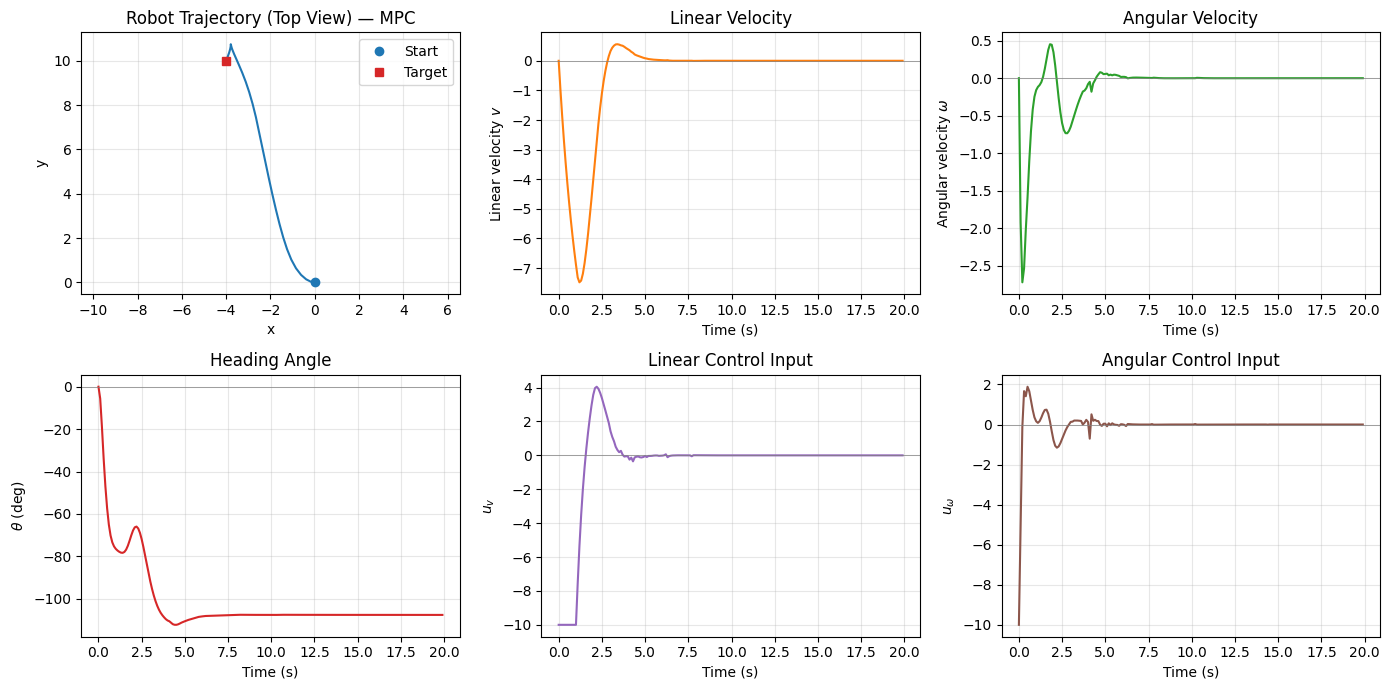

In [5]:
fig0, axes = plt.subplots(2, 3, figsize=(14, 7))

ax_traj, ax_v, ax_omega, ax_theta, ax_u_v, ax_u_omega = axes.flat

ax_traj.plot(x_hist, y_hist, color='C0', lw=1.5)
ax_traj.plot(0, 0, 'o', color='C0', label="Start")
ax_traj.plot(x_target, y_target, 's', color='C3', label="Target")
ax_traj.set_xlabel("x")
ax_traj.set_ylabel("y")
ax_traj.set_title("Robot Trajectory (Top View) — MPC")
ax_traj.axis('equal')
ax_traj.legend()
ax_traj.grid(True, alpha=0.3)

t_vals = times[:-1]

ax_v.plot(t_vals, v_hist[:-1], color='C1')
ax_v.set_xlabel("Time (s)")
ax_v.set_ylabel("Linear velocity $v$")
ax_v.set_title("Linear Velocity")
ax_v.grid(True, alpha=0.3)
ax_v.axhline(0, color='gray', lw=0.5)

ax_omega.plot(t_vals, omega_hist[:-1], color='C2')
ax_omega.set_xlabel("Time (s)")
ax_omega.set_ylabel("Angular velocity $\\omega$")
ax_omega.set_title("Angular Velocity")
ax_omega.grid(True, alpha=0.3)
ax_omega.axhline(0, color='gray', lw=0.5)

ax_theta.plot(t_vals, np.rad2deg(theta_hist[:-1]), color='C3')
ax_theta.set_xlabel("Time (s)")
ax_theta.set_ylabel(r"$\theta$ (deg)")
ax_theta.set_title("Heading Angle")
ax_theta.grid(True, alpha=0.3)
ax_theta.axhline(0, color='gray', lw=0.5)

ax_u_v.plot(t_vals, u_history[:, 0], color='C4')
ax_u_v.set_xlabel("Time (s)")
ax_u_v.set_ylabel("$u_v$")
ax_u_v.set_title("Linear Control Input")
ax_u_v.grid(True, alpha=0.3)
ax_u_v.axhline(0, color='gray', lw=0.5)

ax_u_omega.plot(t_vals, u_history[:, 1], color='C5')
ax_u_omega.set_xlabel("Time (s)")
ax_u_omega.set_ylabel("$u_\\omega$")
ax_u_omega.set_title("Angular Control Input")
ax_u_omega.grid(True, alpha=0.3)
ax_u_omega.axhline(0, color='gray', lw=0.5)

plt.tight_layout()
plt.show()

## 5. Animate Top-Down View

Robot drawn as a circle with a heading-direction line and a fading trail.

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-5, 2)
ax.set_ylim(-1, 12)
ax.set_aspect('equal')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("MPC Differential Drive — Top View")
ax.grid(True, alpha=0.3)

target_marker, = ax.plot(x_target, y_target, 's', color='C3', ms=8, label="Target")
trail_line, = ax.plot([], [], 'C0', lw=1.5, alpha=0.6, label="Trail")
robot_body = plt.Circle((0, 0), 0.3, color='C0', ec='k', zorder=5)
ax.add_patch(robot_body)
heading_line, = ax.plot([], [], 'k-', lw=2)
ax.legend(loc='upper left')

skip = 2
n_ani_frames = len(x_hist[::skip])

def init():
    trail_line.set_data([], [])
    heading_line.set_data([], [])
    return trail_line, heading_line, robot_body

def update(frame):
    idx = frame * skip
    robot_body.center = (x_hist[idx], y_hist[idx])
    trail_line.set_data(x_hist[:idx+1], y_hist[:idx+1])
    th = theta_hist[idx]
    heading_line.set_data(
        [x_hist[idx], x_hist[idx] + 0.5 * np.cos(th)],
        [y_hist[idx], y_hist[idx] + 0.5 * np.sin(th)]
    )
    return trail_line, heading_line, robot_body

ani = FuncAnimation(fig, update, frames=n_ani_frames, init_func=init,
                    interval=50, blit=True)

plt.close(fig)
display(HTML(ani.to_jshtml()))

---

## Summary

- **MPC** solves a finite-horizon optimal control problem at each sampling instant, then applies only the first control action (receding horizon).
- The prediction horizon $N = 15$ and weights $Q, R$ shape the trade-off between fast convergence and control effort.
- Control limits are naturally handled via bounds in the optimizer, which is a key advantage over PID and LQR.
- The main cost is the repeated optimisation; real-time feasibility depends on horizon length and solver speed.